# Ejercicio 1 - 29 de Abril

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co

Tiempo **20 minutos**.

In [24]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from skimage import data as skdata

mpl.rcParams.update({
    "text.usetex": True,            # Activa el renderizado de LaTeX
    "font.family": "serif",         # Usa familia serif
    "font.serif": ["Computer Modern Roman"], # Fuente clásica de LaTeX
    "font.size": 14,                # Tamaño de fuente general más grande
    
    # Ejes y Ticks
    "axes.labelsize": 16,           # Tamaño de etiquetas (x, y)
    "axes.titlesize": 16,           # Tamaño del título
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,    # Mostrar ticks menores en X
    "ytick.minor.visible": True,    # Mostrar ticks menores en Y
    "xtick.direction": "in",        # Ticks hacia adentro (estilo clásico)
    "ytick.direction": "in",
    
    # Estética de la figura
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
})


---
## Imagen 1 — Cameraman

**Respuestas de exploración:**
- `shape = (512, 512)`: array 2D, filas × columnas, sin canal de color
- `dtype = uint8`: entero sin signo de 8 bits → valores en [0, 255]
- `imshow` sin `cmap` usa `viridis` por defecto: mapea [min, max] a colores, aunque el dato sea intensidad

**Problemas del crudo:** colormap falso, ejes con índices de píxel, sin colorbar, sin título.


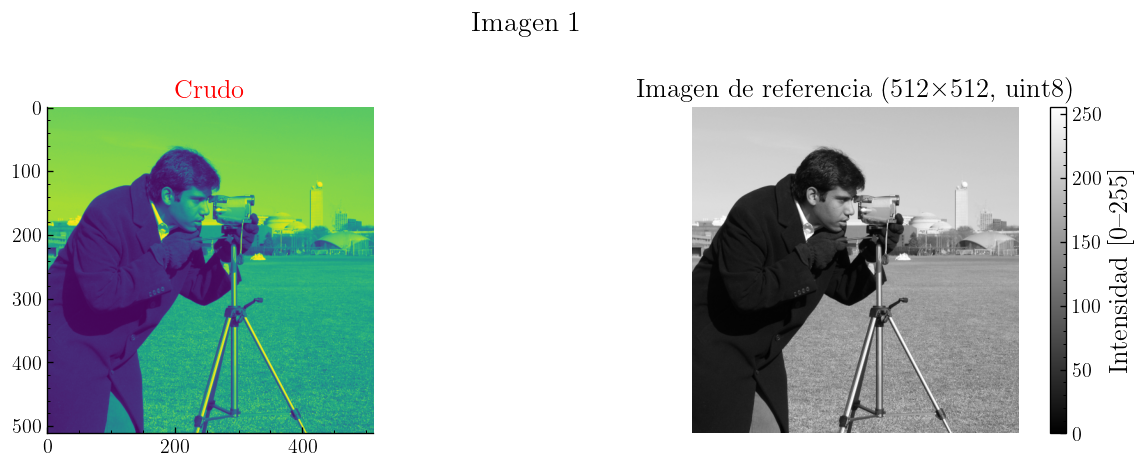

In [25]:
cam = skdata.camera()   # imagen clásica de referencia, 512×512 píxeles

fig, axes = plt.subplots(1, 2, figsize=(11, 4))   # dos paneles: crudo vs mejorado
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/figure_size_units.html

# ── panel izquierdo: crudo ───────────────────────────────────────────────────
axes[0].imshow(cam)                               # viridis por defecto: colores falsos
axes[0].set_title('Crudo', color='red')           # etiqueta para identificar el panel

# ── panel derecho: mejorado ──────────────────────────────────────────────────
im = axes[1].imshow(
    cam,                # array 2D de intensidades
    cmap='gray',        # escala de grises: intensidad = luminancia, sin color arbitrario
    vmin=0,             # mínimo fijo del rango: no relativo al contenido de la imagen
    vmax=255,           # máximo fijo: igual al rango real de uint8
)
axes[1].set_title('Imagen de referencia (512×512, uint8)')  # título informativo
axes[1].axis('off')                                     # elimina ejes: los índices de píxel no aportan
plt.colorbar(im, ax=axes[1], label='Intensidad [0–255]')  # escala visible y etiquetada

plt.suptitle('Imagen 1', fontweight='bold')  # título global de la figura
plt.tight_layout()                   # ajusta márgenes para que nada se solape
plt.show()


---
## Imagen 2 — Astronaut

**Respuestas de exploración:**
- `shape = (512, 512, 3)`: array 3D — filas × columnas × canal de color
- La tercera dimensión son los canales R (0), G (1), B (2)
- `astro[:, :, 0]` extrae solo el canal R → `imshow` lo interpreta como escala de grises con `viridis`

**Problemas del crudo:** descarta G y B, colormap incorrecto para un canal de color, sin contexto.


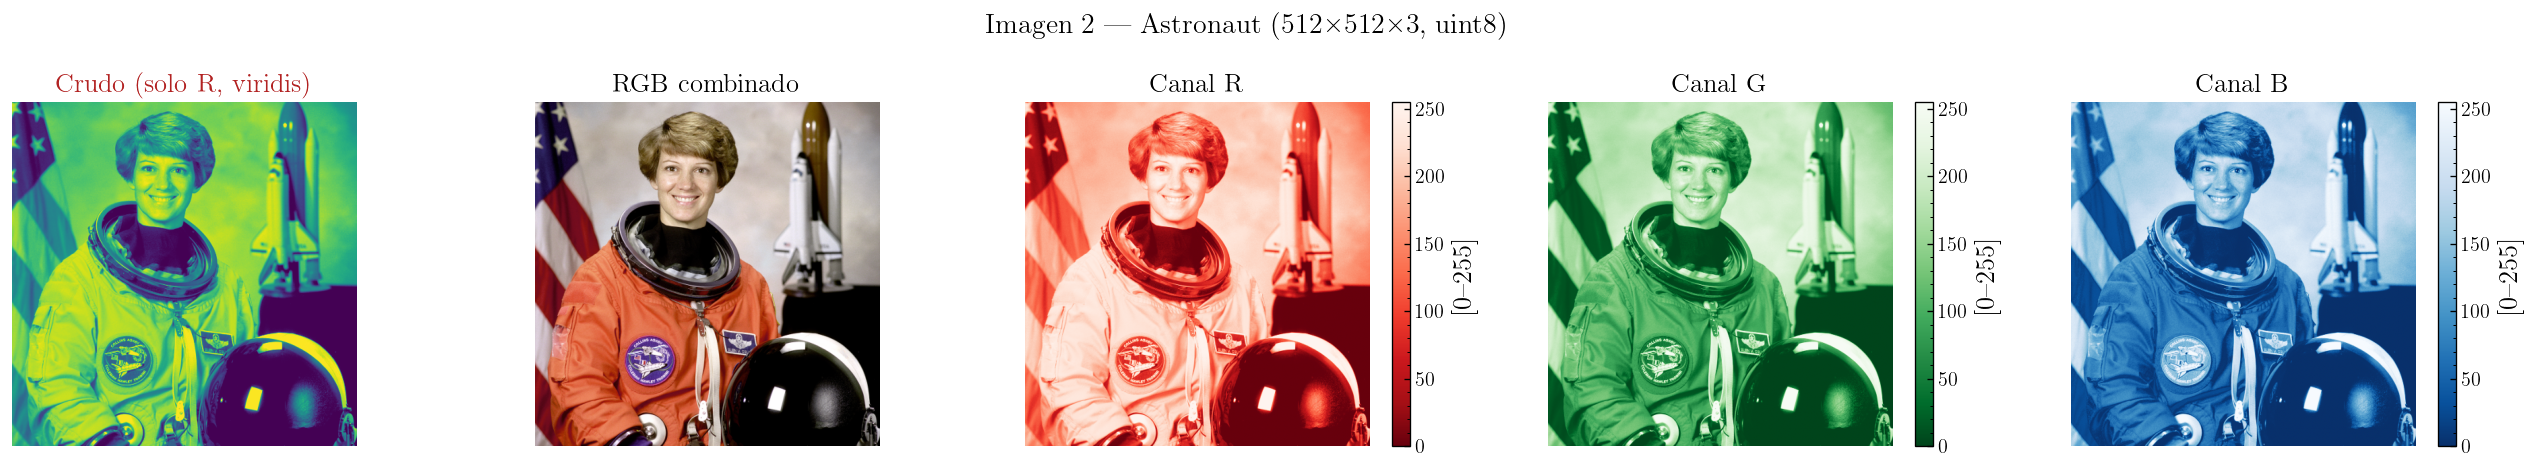

In [26]:
astro = skdata.astronaut()   # imagen RGB clásica, 512×512×3 píxeles

fig, axes = plt.subplots(1, 5, figsize=(22, 4))   # 5 paneles: crudo + RGB + 3 canales

# ── panel 0: crudo ───────────────────────────────────────────────────────────
axes[0].imshow(astro[:, :, 0])                          # solo canal R, viridis: información perdida
axes[0].set_title('Crudo (solo R, viridis)', color='firebrick')
axes[0].axis('off')

# ── panel 1: RGB completo ─────────────────────────────────────────────────────
#axes[1].imshow(astro[:, :, 0]+astro[:, :, 1]+astro[:, :, 2]) 
axes[1].imshow(astro)                                    # array 3D: imshow interpreta eje 2 como RGB
axes[1].set_title('RGB combinado')                      # la imagen tal como fue capturada
axes[1].axis('off')

# ── paneles 2-4: canales individuales ────────────────────────────────────────
configs = [
    (astro[:, :, 0], 'Canal R', 'Reds_r'),    # canal rojo con colormap que refuerza la semántica
    (astro[:, :, 1], 'Canal G', 'Greens_r'),  # canal verde
    (astro[:, :, 2], 'Canal B', 'Blues_r'),   # canal azul
]
for ax, (canal, nombre, cmap) in zip(axes[2:], configs):
    im = ax.imshow(
        canal,          # array 2D del canal individual
        cmap=cmap,      # colormap semántico: rojo para R, verde para G, azul para B
        vmin=0,         # rango fijo para comparación justa entre canales
        vmax=255,
    )
    ax.set_title(nombre)
    ax.axis('off')                                       # los índices de píxel no aportan
    plt.colorbar(im, ax=ax, label='[0–255]')  # escala de intensidad por canal

plt.suptitle('Imagen 2 — Astronaut (512×512×3, uint8)', fontweight='bold')
plt.tight_layout()
plt.show()



---
## Imagen 3 — Temperatura superficial global

**Respuestas de exploración:**
- `shape = (180, 360)`: filas = latitudes (−90° a 90°), columnas = longitudes (−180° a 180°)
- `dtype = float64`: dato continuo, no entero — no tiene un rango fijo como uint8
- El dato es **divergente**: tiene valores positivos y negativos con significado físico en el cero
- Colormap apropiado: divergente centrado en 0 → `RdBu_r` (azul=frío, rojo=calor)

**Problemas del crudo:** `viridis` no marca el cero, ejes en índices de array (no grados),
sin colorbar, norte abajo por `origin='upper'` por defecto.


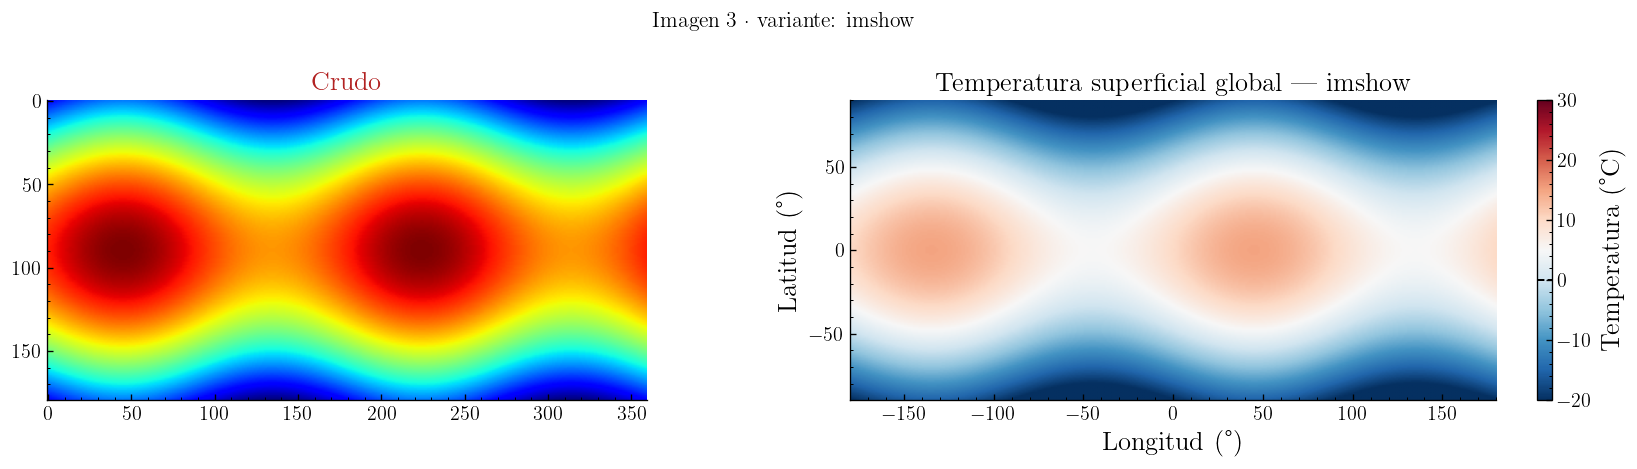

In [31]:
# ── datos ────────────────────────────────────────────────────────────────────
lat = np.linspace(-90, 90, 180)          # latitudes de polo sur a polo norte
lon = np.linspace(-180, 180, 360)        # longitudes de oeste a este
LON, LAT = np.meshgrid(lon, lat)         # grilla 2D necesaria para contourf y plot_surface
rng = np.random.default_rng(42)          # semilla fija: resultados reproducibles
T = (30 * np.cos(np.radians(LAT))        # máximo en ecuador (~30 °C), mínimo en polos (~-20 °C)
     - 20                                # desplazamiento: temperatura base negativa
     + 5 * np.sin(np.radians(2 * LON)))   # variación longitudinal de ±5 °C
     #+ 3 * rng.standard_normal((180, 360)))  # ruido de ±3 °C: variabilidad local

# ── crudo vs mejorado: imshow ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].imshow(T, cmap='jet')                                       # sin argumentos: viridis, ejes en píxeles
axes[0].set_title('Crudo', color='firebrick')

im = axes[1].imshow(
    T,                              # campo de temperatura 2D
    cmap='RdBu_r',                  # divergente: azul=frío, rojo=calor, blanco=0 °C
    extent=[-180, 180, -90, 90],    # mapea ejes a grados reales en lugar de índices de array
    origin='lower',                 # latitud crece hacia arriba, como en un mapa geográfico
    aspect='auto',                  # permite que la figura no quede distorsionada
    vmin=-20,                       # rango fijo y simétrico alrededor del cero
    vmax=30,
)
cbar = plt.colorbar(im, ax=axes[1], label='Temperatura (°C)')  # escala con unidades físicas
cbar.ax.axhline(0, color='k', linewidth=1.2, linestyle='--')   # marca visual del 0 °C en la barra
axes[1].set_xlabel('Longitud (°)')  # ejes con unidades: los números tienen significado físico
axes[1].set_ylabel('Latitud (°)')
axes[1].set_title('Temperatura superficial global — imshow')

plt.suptitle('Imagen 3 · variante: imshow', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


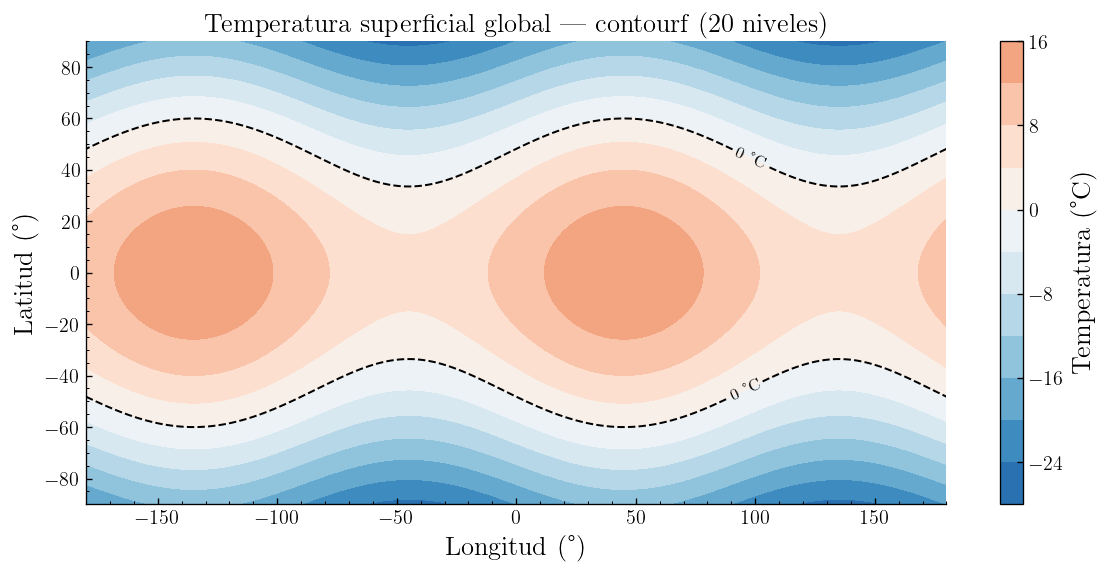

In [28]:
# ── variante: contourf ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

cf = ax.contourf(
    LON, LAT, T,        # coordenadas reales en lugar de índices: ejes en grados automáticamente
    levels=10,          # número de bandas de color: más niveles = más detalle, más ruido visual
    cmap='RdBu_r',      # mismo colormap divergente que en imshow: consistencia visual
    vmin=-35,           # rango fijo y simétrico
    vmax=35,
)
cs = ax.contour(
    LON, LAT, T,        # contorno superpuesto sobre el relleno
    levels=[0],         # solo la isoterma de 0 °C: frontera física frío/calor
    colors='k',         # negro: contrasta con cualquier colormap
    linewidths=1.2,
    linestyles='--',    # discontinua: visualmente distinta de bordes de contourf
)
ax.clabel(cs, fmt='0 °C', fontsize=10)  # etiqueta la isoterma directamente en el mapa

cbar = plt.colorbar(cf, ax=ax, label='Temperatura (°C)')  # escala con unidades
ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')
ax.set_title('Temperatura superficial global — contourf (20 niveles)')
plt.tight_layout()
plt.show()


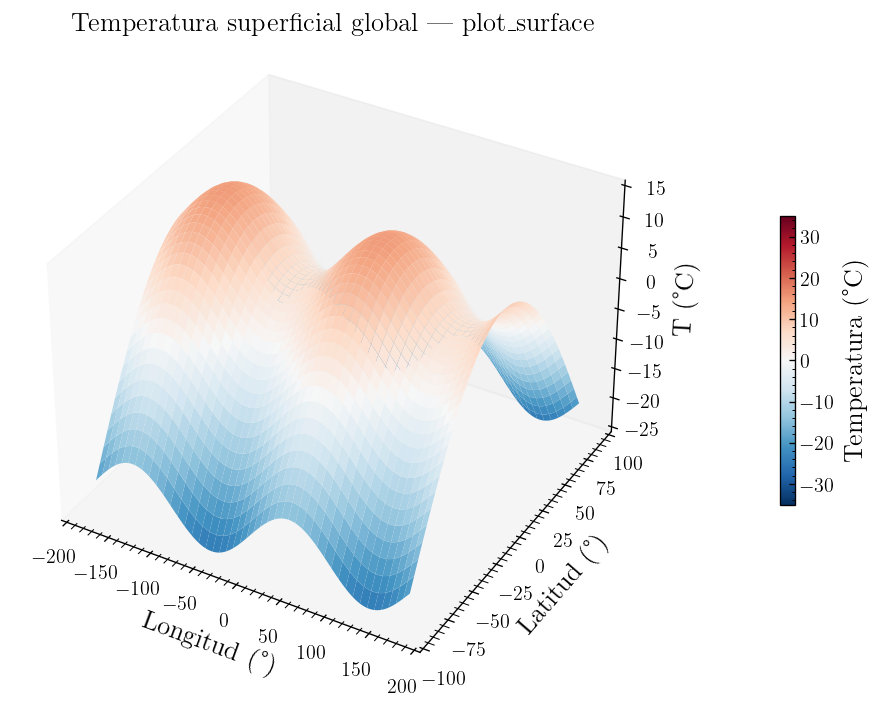

In [ ]:
# ── variante: plot_surface ───────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 6))
ax  = fig.add_subplot(111, projection='3d')   # ejes 3D: necesita Axes3D importado

surf = ax.plot_surface(
    LON, LAT, T,            # X=longitud, Y=latitud, Z=temperatura
    cmap='RdBu_r',          # mismo colormap: altura y color codifican la misma variable
    vmin=-35, vmax=35,      # rango fijo: consistente con las otras dos representaciones
    linewidth=0            # sin bordes entre celdas: superficie más limpia
)
fig.colorbar(surf, ax=ax, shrink=0.45, pad=0.1, label='Temperatura (°C)')  # colorbar adaptada a 3D
ax.set_xlabel('Longitud (°)')   # etiqueta del eje X
ax.set_ylabel('Latitud (°)')    # etiqueta del eje Y
ax.set_zlabel('T (°C)')         # etiqueta del eje Z: la variable representada como altura
ax.set_title('Temperatura superficial global — plot_surface')
ax.view_init(elev=35, azim=-60) # ángulo de cámara: elev=elevación, azim=azimut

# solo líneas de cuadrícula principales para no saturar la vista
ax.grid(False)

plt.tight_layout()
plt.show()
